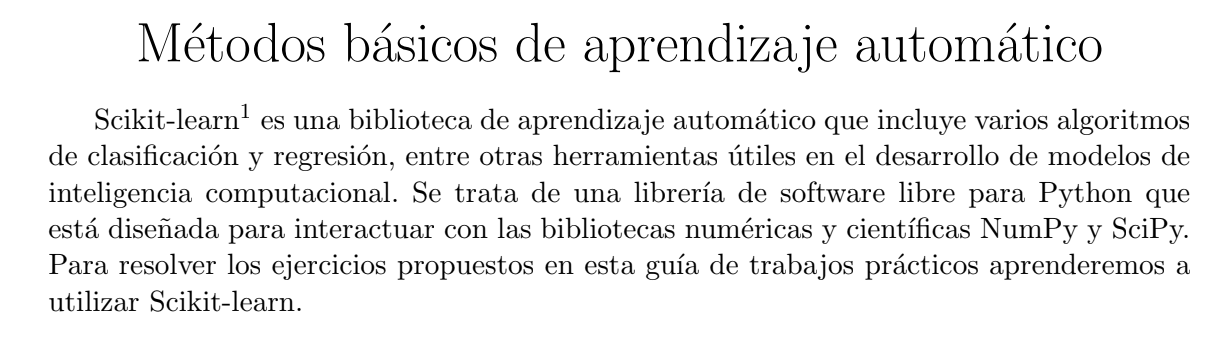

In [86]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold

In [87]:
def imprimir(resultados, nombre, k = 5):

    
    if nombre == 'Bagging' or nombre == 'AdaBoost':
        print('Ensamble:', nombre)
    else:
        print('Modelo:', nombre)

    print('Método de evaluación: KFold de', k, 'particiones')

    print('Aciertos:',end=' ')
    for it in resultados:
        acierto = round(it*100,2)
        print(acierto, '%', sep='',end='   ')

    print()
    media = round(np.mean(resultados)*100,2)
    varianza = np.var(resultados)
    print('Media:',end=' ')
    print(media,'%',sep='')
    print('Varianza',varianza)
    print()

In [88]:
def evaluar_kfold(k, modelo):

    kf = KFold(n_splits=k, shuffle=True, random_state=2077)

    resultados = []

    for train, test in kf.split(X):

        X_train = X[train]
        y_train = y[train]

        X_test = X[test]
        y_test = y[test]

    
        modelo.fit(X_train, y_train)

        aciertos = modelo.score(X_test, y_test)

        resultados.append(aciertos)

    return resultados

In [89]:
def graficar(nombres, resultados, titulo = 'Aciertos por modelo en KFold', xlabel = 'Modelos'):

    plt.figure(figsize=(10, 6))

    for i in range(len(nombres)):
        aciertos = np.array(resultados[i]) * 100
        x = np.full(len(aciertos), i)

        plt.scatter(x, aciertos)

    plt.xticks(range(len(nombres)), nombres)
    plt.xlabel(xlabel)
    plt.ylabel('Porcentaje de aciertos')
        
    plt.title(titulo)
    plt.grid(axis='y')

    plt.show()

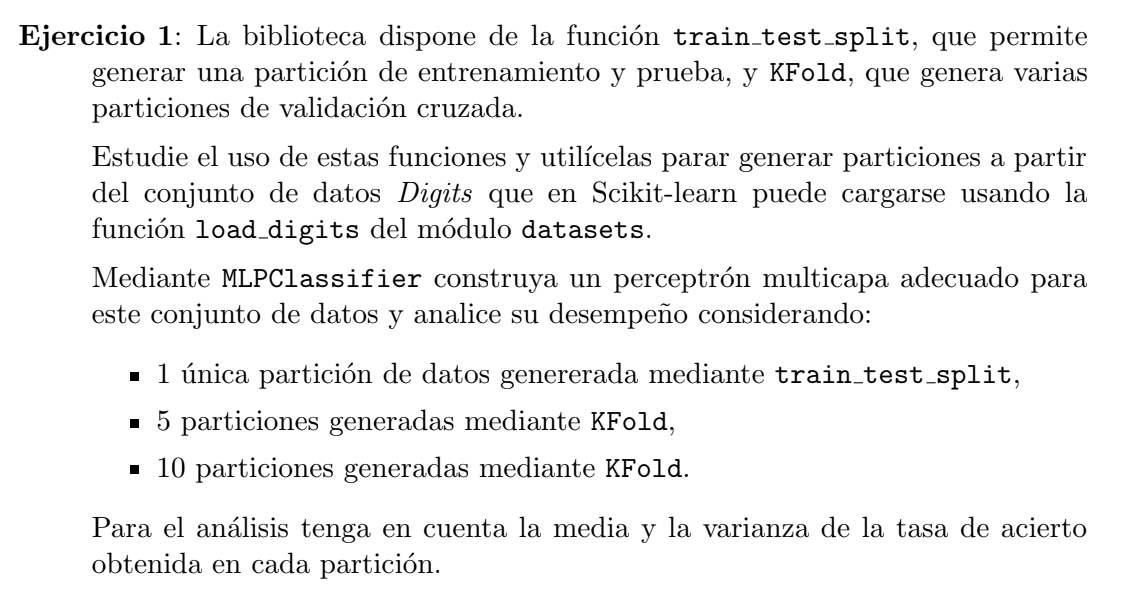

In [90]:
digits = load_digits()

X = digits.data
y = digits.target

In [91]:
print('Modelo: Perceptrón multicapa')
print('Metodo de evaluación: Particion 20% (Split)')

modelo = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=2077)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2077)

print('Train:', X_train.shape[0])
print('Test:', X_test.shape[0])
print('Total:', X_train.shape[0] + X_test.shape[0])

modelo.fit(X_train, y_train)
aciertos = modelo.score(X_test, y_test)*100

print('Aciertos:', end=' ') 
print(round(aciertos,2), '%',sep='')

Modelo: Perceptrón multicapa
Metodo de evaluación: Particion 20% (Split)
Train: 1437
Test: 360
Total: 1797
Aciertos: 95.0%


In [92]:
ks = [5, 10]

nombre = 'Perceptrón multicapa'

titulo = 'Aceritos en Perceptrón multicapa con KFold'

xlabel = 'Particiones de KFold'

etiquetas = ['KFold = 5', 'KFold = 10']

modelos = [MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=2077), 
           MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=2077)]

Modelo: Perceptrón multicapa
Método de evaluación: KFold de 5 particiones
Aciertos: 94.72%   96.94%   93.87%   94.71%   93.59%   
Media: 94.77%
Varianza 0.00013851209379577928

Modelo: Perceptrón multicapa
Método de evaluación: KFold de 10 particiones
Aciertos: 95.56%   95.56%   92.78%   98.33%   93.33%   95.56%   95.0%   96.65%   96.65%   91.06%   
Media: 95.05%
Varianza 0.0004067538177358407



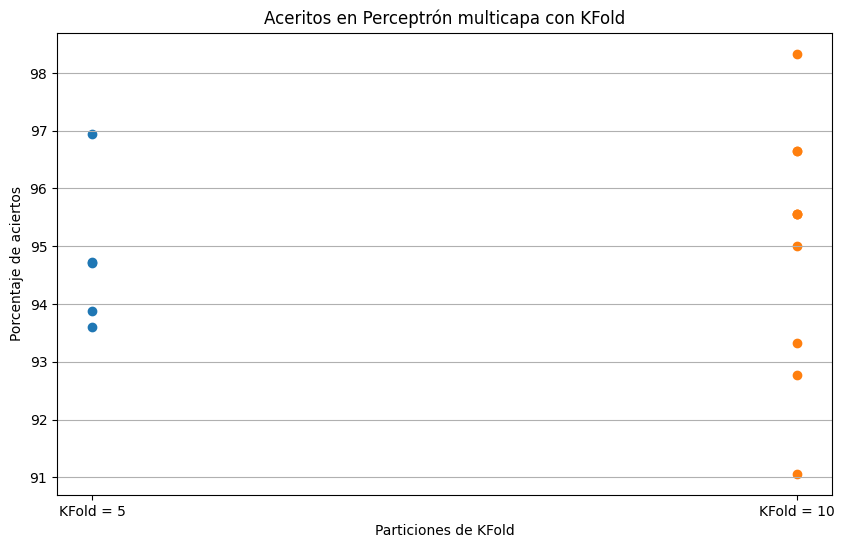

In [93]:
datos = []
for i in range(len(ks)):

    resultados = evaluar_kfold(ks[i], modelos[i])
    imprimir(resultados, nombre, ks[i])
    datos.append(resultados)

graficar(etiquetas, datos, titulo, xlabel)

## Análisis de resultados — Ejercicio 1

Se evaluó el desempeño de un perceptrón multicapa utilizando una partición del 20% y los métodos KFold con 5 y 10 particiones.

Con la partición del 20%, se obtuvo un porcentaje de aciertos del 95% sobre el conjunto de prueba.

Al utilizar **KFold con 5 particiones**, los porcentajes de aciertos estuvieron entre **93,59% y 96,94%**, obteniendo una media de **94,77%** y una varianza de **0,0001385**.

Por otro lado, con **KFold de 10 particiones**, los resultados estuvieron entre **91,06% y 98,33%**, con una media de **95,05%** y una varianza de **0,0004068**.

Comparando los resultados, KFold=10 obtuvo la **mayor media de aciertos**, aunque también presentó una **mayor varianza**, lo que indica que los resultados fueron más variables entre las distintas particiones. KFold=5 obtuvo una media ligeramente menor, pero presentó una varianza considerablemente menor, por lo que sus resultados fueron más estables.

La partición del 20% obtuvo un resultado de **95,56%**, similar a las medias obtenidas mediante KFold. Sin embargo, al utilizar una única partición no es posible analizar la variabilidad del modelo frente a diferentes conjuntos de entrenamiento y prueba.

En conclusión, **KFold=10 obtuvo el mejor rendimiento promedio**, mientras que **KFold=5 presentó mayor estabilidad** en los resultados. Las diferencias de rendimiento entre los tres métodos fueron relativamente pequeñas.

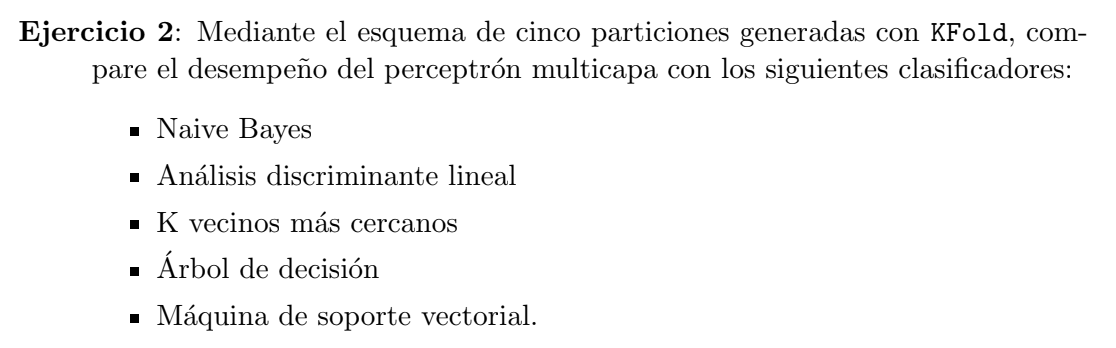

In [94]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [95]:
nombres = ['Naive Bayes', 
           'Análisis discriminante lineal (ADL)', 
           'K vecinos mas cercanos (KNN)', 
           'Árbol de decision', 
           'Máquina de soporte vectorial (MSV)']

modelos = [GaussianNB(), 
           LinearDiscriminantAnalysis(), 
           KNeighborsClassifier(), 
           DecisionTreeClassifier(random_state=2077), 
           SVC(random_state=2077)]

etiquetas = ['NaiveBayes', 'ADL', 'KNN', 'Árbol', 'MSV']

Modelo: Naive Bayes
Método de evaluación: KFold de 5 particiones
Aciertos: 82.5%   85.83%   77.99%   84.96%   84.12%   
Media: 83.08%
Varianza 0.0007678979920322708

Modelo: Análisis discriminante lineal (ADL)
Método de evaluación: KFold de 5 particiones
Aciertos: 95.56%   93.61%   93.87%   95.82%   96.38%   
Media: 95.05%
Varianza 0.0001215062971766181

Modelo: K vecinos mas cercanos (KNN)
Método de evaluación: KFold de 5 particiones
Aciertos: 98.89%   98.33%   98.33%   99.44%   98.05%   
Media: 98.61%
Varianza 2.481224664996264e-05

Modelo: Árbol de decision
Método de evaluación: KFold de 5 particiones
Aciertos: 87.5%   85.0%   87.19%   85.24%   85.52%   
Media: 86.09%
Varianza 0.00010874062119319407

Modelo: Máquina de soporte vectorial (MSV)
Método de evaluación: KFold de 5 particiones
Aciertos: 99.72%   98.89%   98.33%   98.89%   98.05%   
Media: 98.78%
Varianza 3.2941815116844886e-05



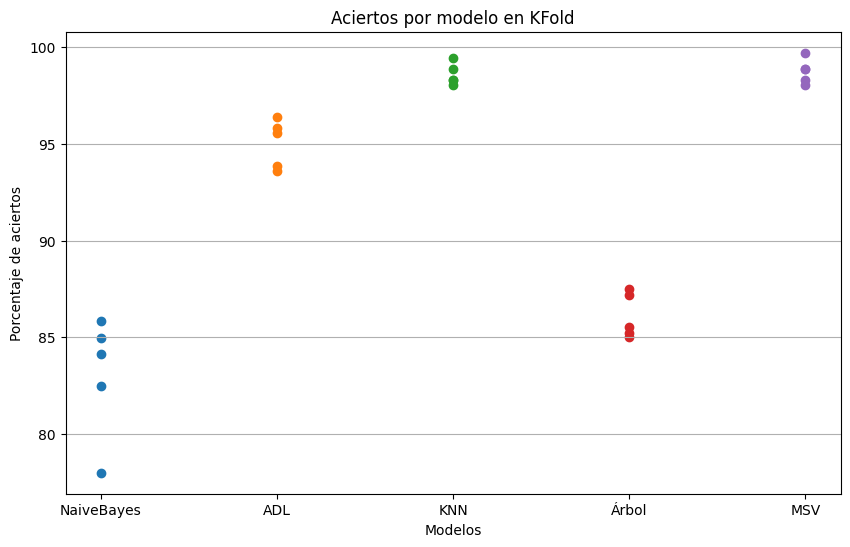

In [96]:
datos = []
for i in range(len(nombres)):

    resultados = evaluar_kfold(5, modelos[i])
    imprimir(resultados, nombres[i])
    datos.append(resultados)

graficar(etiquetas,datos)

## Análisis de resultados — Ejercicio 2

En este ejercicio se comparó el desempeño del perceptrón multicapa con distintos clasificadores utilizando 5 particiones mediante KFold. Como referencia, el perceptrón multicapa obtuvo en el Ejercicio 1 una media de **94,77%** y una varianza de **0,0001385**.

El clasificador **Naive Bayes** obtuvo una media de **83,08%**, siendo el que presentó el menor rendimiento de todos los modelos evaluados. Además, tuvo una varianza de **0,0007679**, la más alta, indicando una mayor variabilidad entre las particiones.

El **Análisis Discriminante Lineal (ADL)** obtuvo una media de **95,05%**, ligeramente superior al perceptrón multicapa. Su varianza fue de **0,0001215**, menor que la del MLP, por lo que presentó resultados ligeramente más estables.

El algoritmo de **K vecinos más cercanos (KNN)** obtuvo una media de **98,61%**, superando ampliamente al perceptrón multicapa. Además, presentó una varianza muy baja de **0,0000248**, indicando una gran estabilidad entre las distintas particiones.

El **Árbol de Decisión** obtuvo una media de **86,09%**, inferior a la del perceptrón multicapa, aunque presentó una varianza de **0,0001087**, ligeramente menor que la del MLP.

Finalmente, la **Máquina de Soporte Vectorial (MSV)** obtuvo la mayor media de aciertos, con **98,78%**, superando ligeramente a KNN. Su varianza fue de **0,0000329**, por lo que también presentó resultados muy estables.

En conclusión, los mejores resultados fueron obtenidos por **MSV y KNN**, ambos con una precisión cercana al 99% y una baja variabilidad. El **ADL** tuvo un rendimiento similar al perceptrón multicapa, mientras que **Naive Bayes y el Árbol de Decisión** obtuvieron resultados considerablemente inferiores. En este conjunto de datos y con la configuración utilizada, los resultados indican un mejor desempeño de KNN y MSV frente al perceptrón multicapa.

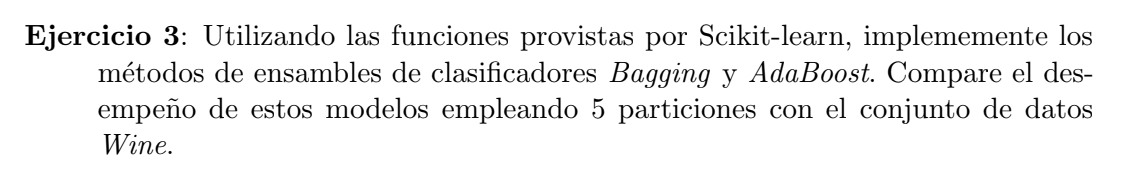

In [97]:
from sklearn.datasets import load_wine
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

In [98]:
nombres = ['Bagging', 'AdaBoost']

titulo = 'Aciertos por ensamble en KFold'

xlabel = 'Ensambles'

modelos = [BaggingClassifier(random_state=2077), AdaBoostClassifier(random_state=2077)]

In [99]:
wine = load_wine()
X = wine.data
y = wine.target

Ensamble: Bagging
Método de evaluación: KFold de 5 particiones
Aciertos: 94.44%   97.22%   97.22%   97.14%   97.14%   
Media: 96.63%
Varianza 0.00012008062484252973

Ensamble: AdaBoost
Método de evaluación: KFold de 5 particiones
Aciertos: 97.22%   100.0%   94.44%   88.57%   97.14%   
Media: 95.48%
Varianza 0.0015006298815822634



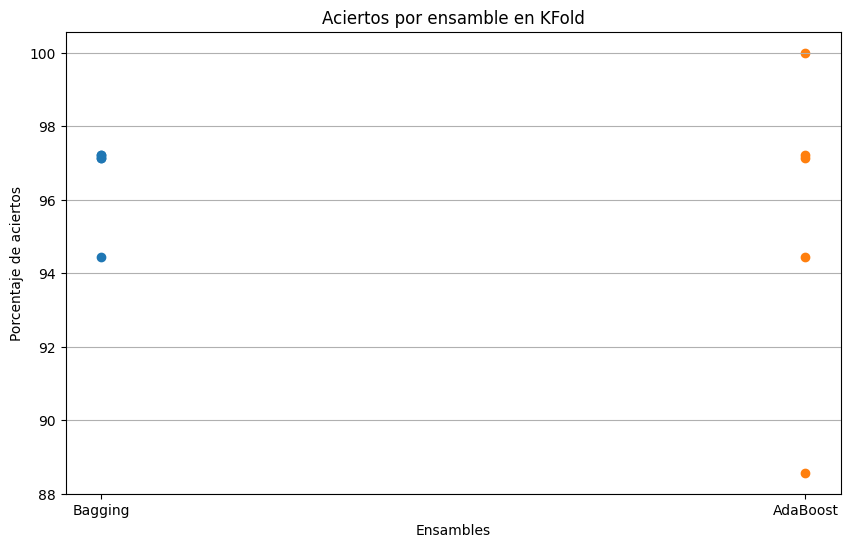

In [100]:
datos = []
for i in range(len(nombres)):

    resultados = evaluar_kfold(5, modelos[i])
    imprimir(resultados, nombres[i])
    datos.append(resultados)

graficar(nombres, datos, titulo, xlabel)

## Análisis de resultados — Ejercicio 3

En este ejercicio se comparó el desempeño de los métodos de ensamble Bagging y AdaBoost utilizando el conjunto de datos Wine y 5 particiones mediante KFold.

El modelo **Bagging** obtuvo porcentajes de aciertos entre **94,44% y 97,22%**, con una media de **96,63%** y una varianza de **0,0001201**. Los resultados fueron bastante similares entre las distintas particiones, lo que indica una buena estabilidad.

Por otro lado, **AdaBoost** obtuvo resultados entre **88,57% y 100%**, alcanzando una media de **95,48%** y una varianza de **0,0015006**. Si bien obtuvo el máximo porcentaje de aciertos en una de las particiones, presentó una variabilidad considerablemente mayor entre los distintos conjuntos de prueba.

Al comparar ambos métodos, **Bagging obtuvo una mayor media de aciertos y una varianza considerablemente menor que AdaBoost**. Por lo tanto, para este conjunto de datos y con la configuración utilizada, Bagging presentó un mejor desempeño promedio y resultados más estables.

En conclusión, **Bagging fue el método de ensamble que obtuvo mejores resultados en esta evaluación**, tanto por su mayor precisión promedio como por su menor variabilidad entre las particiones.

## Conclusión

A partir de los resultados obtenidos, se puede observar que el desempeño de los modelos depende tanto del algoritmo utilizado como del conjunto de datos y del método de evaluación. En el primer ejercicio, el perceptrón multicapa obtuvo resultados cercanos al 95% de aciertos, mostrando un desempeño estable con KFold. En el segundo ejercicio, los mejores resultados fueron obtenidos por KNN y la máquina de soporte vectorial, superando al perceptrón multicapa. Finalmente, en el tercer ejercicio, Bagging obtuvo un mejor desempeño promedio y una menor variabilidad que AdaBoost sobre el conjunto de datos Wine.

En general, los experimentos muestran la importancia de comparar distintos modelos y utilizar métodos de validación como KFold para obtener una evaluación más representativa de su desempeño.